In [ ]:
"""
Script: 
    Monte Hall Problem Simulation.ipynb

Purpose: 
    Simulates running Monte Hall Problem many times. Show probability of 
    winning when switching guesses and when not switching guesses.

Usage: 
    Run in Jupyter Notebok

Development Status: 
    Complete

Dev Notes: 
    psuedocode:
        -- Main Alg
        1. Randomly define one out of three options as Prize
        2. User selects a random option
        3. Reveal option not containing Prize & not containing user selection
        4. User given opportunity to select another option 
    
        -- Stats out for analysis
        1. Percentage of selecting Prize option
    
        -- Test Cases
        1. User never switches case in step 3
        2. User always switches case in step 3
    
        -- Architechure
        - Define function with main alg
        - Loop over main function user-defined number of times
        - report results
    
        -- Cool figures
        - Figure with errorbar on y-axis showing average value of winning with both cases vs the number of times played
            - example: run 10000 times with 1000 iterations per time. 

Revision History:
    ----------------------------------------------------------------------------------------------------------------
    |  ID  |  Author     |     Date       |       Description
    -----------------------------------------------------------------------------------------------------------------
    |  0   | M.Pogash    |  08-May-2026   | - Initial Drop   

"""

(0.0, 1.0)

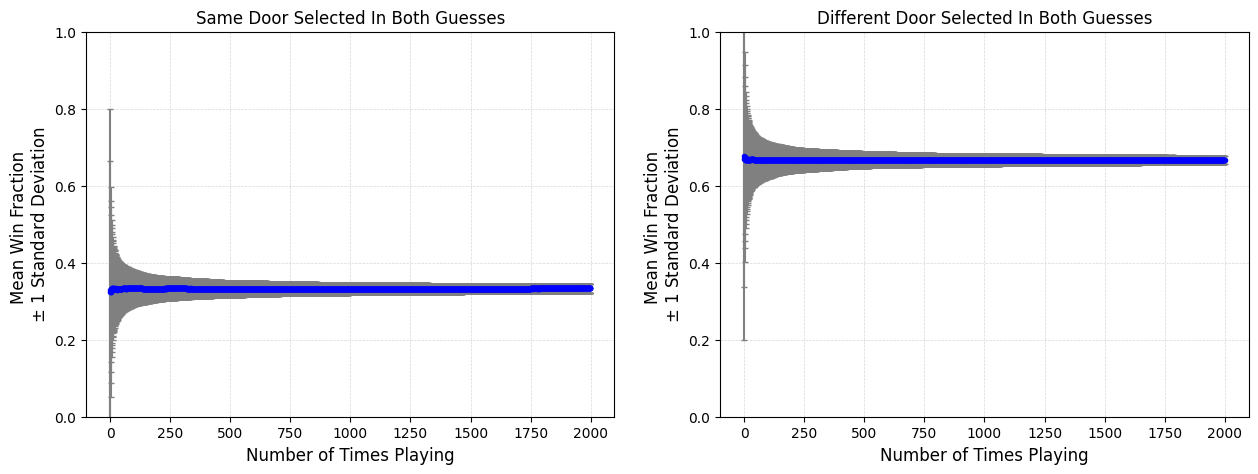

In [193]:
# == Import Libraries ====================================
import numpy as np
import matplotlib.pyplot as plt

## == User Inputs ========================================
num_evals_per_sim = 2000
num_sims = 1000

## == Function Definition ================================
def evaluate_monte_hall_problem():
    # import libraries
    import random
    
    # define options for user to select
    user_options = [1, 2, 3]
    
    # define random option as prize
    prize_option = random.randint(1,3)
    
    # user selects random option
    user_selection = random.randint(1,3)
    
    # reveal option not containing prize 
    reveal_option = user_options.copy()
    reveal_option.remove(prize_option)
    if prize_option == user_selection: 
        reveal_option.pop(random.randint(0,1))
    else:
        reveal_option.remove(user_selection)
    reveal_option = reveal_option[0]
    
    # remove the reveal option from user options
    user_options.remove(reveal_option)
    
    # let user select new option
    # case 1. user selects same option
    user_selection_same = user_selection
    
    # case 2. user selects new selection
    user_selection_switch = user_options.copy()
    user_selection_switch.remove(user_selection)
    user_selection_switch = user_selection_switch[0]
    
    # determine if correct or not
    correct_flag_same_user_option = user_selection_same == prize_option
    correct_flag_switch_user_option = user_selection_switch == prize_option
    return correct_flag_same_user_option, correct_flag_switch_user_option

## == Code ===============================================

## == Loop over evaluate_monte_hall_problem ==============
percent_win_same_user_option = []
percent_win_switch_user_option = []
# -- These lines would skip evaluaring every num_evals_per_sim and 
#    only work in batches, but, need to update lines below that compute
#    percentiles... may fix later
#if num_evals_per_sim > 100:
#    tot_sims = 100
#    step_size = np.floor(num_evals_per_sim//tot_sims)
#n_evals_array = range(0,num_evals_per_sim,step_size) 
#print(f"n_evals_array is {n_evals_array}")
n_evals_array = range(num_evals_per_sim)
for ss in range(num_sims): 
    percent_win_same_user_option_sim_ii = []
    percent_win_switch_user_option_sim_ii = []
    correct_score_same_user_option = 0
    coreect_score_switch_user_option = 0
    for ii in n_evals_array: #range(num_evals_per_sim):
        correct_flag_same_user_option, correct_flag_switch_user_option = evaluate_monte_hall_problem()
        if correct_flag_same_user_option == True:
            correct_score_same_user_option += 1
        if correct_flag_switch_user_option == True:
            coreect_score_switch_user_option += 1
        correct_fraction_same_user_option = correct_score_same_user_option/(ii+1)
        correct_fraction_switch_user_option = coreect_score_switch_user_option/(ii+1)
        percent_win_same_user_option_sim_ii.append(correct_fraction_same_user_option)
        percent_win_switch_user_option_sim_ii.append(correct_fraction_switch_user_option)

    percent_win_same_user_option.append(percent_win_same_user_option_sim_ii)
    percent_win_switch_user_option.append(percent_win_switch_user_option_sim_ii)

# == Analyze results ====================================
percent_win_same_user_option = np.array(percent_win_same_user_option)
percent_win_switch_user_option = np.array(percent_win_switch_user_option)

mean_percent_win_same_user_option = np.mean(percent_win_same_user_option,axis=0)
std_percent_win_same_user_option = np.std(percent_win_same_user_option,axis=0)

mean_percent_win_switch_user_option = np.mean(percent_win_switch_user_option,axis=0)
std_percent_win_switch_user_option = np.std(percent_win_switch_user_option,axis=0)

mean_percent_win_switch_user_option
# == Visualize Results ==================================
fs = 12
fig, fig_ax = plt.subplots(1, 2, figsize=[15,5])

fig_ax[0].errorbar(n_evals_array,mean_percent_win_same_user_option,yerr=std_percent_win_same_user_option,fmt='o',capsize=2, \
            ecolor=[.5, .5, .5], mfc=[0, 0, 1], mec = [0, 0, 1], ms = 3)
fig_ax[0].set_title("Same Door Selected In Both Guesses",fontsize=fs)
fig_ax[0].set_xlabel("Number of Times Playing",fontsize=fs)
fig_ax[0].set_ylabel(f"Mean Win Fraction \n" + r"$\pm$ 1 Standard Deviation",fontsize=fs)
fig_ax[0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
fig_ax[0].set_ylim(0, 1)


fig_ax[1].errorbar(n_evals_array,mean_percent_win_switch_user_option,yerr=std_percent_win_switch_user_option,fmt='o',capsize=2, \
            ecolor=[.5, .5, .5], mfc=[0, 0, 1], mec = [0, 0, 1], ms =3)
fig_ax[1].set_title("Different Door Selected In Both Guesses",fontsize=fs)
fig_ax[1].set_xlabel("Number of Times Playing",fontsize=fs)
fig_ax[1].set_ylabel(f"Mean Win Fraction \n" + r"$\pm$ 1 Standard Deviation",fontsize=fs)
fig_ax[1].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
fig_ax[1].set_ylim(0, 1)